## EV Route Finding System

In [1]:
import pandas as pd
import networkx as nx
from geopy.distance import geodesic
import random
from sklearn.cluster import DBSCAN
import numpy as np
from collections import defaultdict
import math
import pickle

In [2]:
# Load
with open("graph_data.gpickle", "rb") as f:
    G = pickle.load(f)

## Filtering Nodes Selected

In [3]:
def filter_path_by_distance(path, graph, min_km=175, max_km=225):
    if not path or len(path) < 2:
        return path

    filtered_path = [path[0]]
    current = path[0]
    i = 1

    while i < len(path):
        found = False
        for j in range(i, len(path)):
            dist = geodesic(graph.nodes[current]['pos'], graph.nodes[path[j]]['pos']).km
            if min_km <= dist <= max_km:
                filtered_path.append(path[j])
                current = path[j]
                i = j + 1
                found = True
                break
        if not found:
            filtered_path.append(path[i])
            current = path[i]
            i += 1

    return filtered_path


## On-Road Distance Analysis(Actual Accuracy of the Model) using ORS:

[(-81.96395494070738, 28.159543475832265), (-82.18665229506666, 29.162481371888887), (-82.768997, 31.031873), (-83.52709487982396, 31.449144219852315), (-83.266285, 33.12971866666667), (-83.3232515, 33.468328), (-83.39266520374737, 33.94462319562608), (-84.32069266741782, 33.869445938113344)]
Route from point 0 to 1: 123093.70 m
Route from point 1 to 2: 248967.00 m
Route from point 2 to 3: 95549.60 m
Route from point 3 to 4: 221492.90 m
Route from point 4 to 5: 49490.20 m
Route from point 5 to 6: 78304.90 m
Route from point 6 to 7: 99465.90 m

✅ Total real-world road distance: 916.36 km


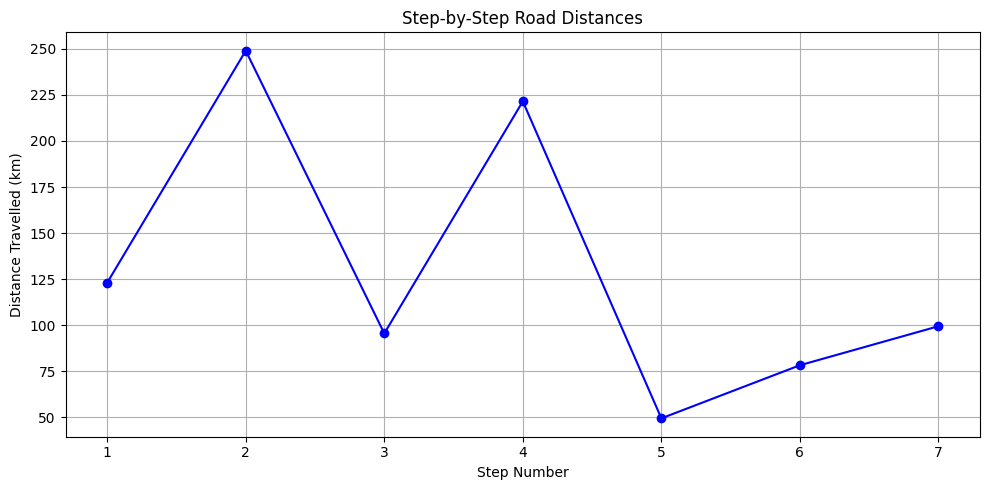

In [ ]:
import openrouteservice
import matplotlib.pyplot as plt 

# Replace with your actual OpenRouteService API key
ORS_API_KEY = "API-Key"

# Load coordinates (in (lat, lon) format)
coords = []
with open("ev-routing-coordinates-dual-q-filtering.txt", "r") as f:
    for line in f:
        lon, lat = map(float, line.strip().split(','))
        coords.append((lon, lat))  # ORS expects (lon, lat)
print(coords)
# Initialize ORS client
client = openrouteservice.Client(key=ORS_API_KEY)

# Calculate total road distance
total_distance = 0
start_idx = 0
step_distances = []

for end_idx in range(1, len(coords)):
    try:
        res = client.directions(
            coordinates=[coords[start_idx], coords[end_idx]],
            profile='driving-car',
            format='geojson',
            radiuses=[1000, 1000]
        )
        dist = res['features'][0]['properties']['segments'][0]['distance']  # in meters
        total_distance += dist
        step_distances.append(dist / 1000)  # convert to kilometers
        print(f"Route from point {start_idx} to {end_idx}: {dist:.2f} m")

        start_idx = end_idx  # Move to next valid start point
    except Exception as e:
        print(f"⚠️ No route from point {start_idx} to {end_idx}: skipping point {end_idx}")

print(f"\n✅ Total real-world road distance: {total_distance/1000:.2f} km")

# Plot step-wise distances
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(step_distances)+1), step_distances, marker='o', linestyle='-', color='blue')
plt.title("Step-by-Step Road Distances")
plt.xlabel("Step Number")
plt.ylabel("Distance Travelled (km)")
plt.grid(True)
plt.xticks(range(1, len(step_distances)+1))
plt.tight_layout()
plt.show()


In [5]:
on_road_distance = 710
total_distance=total_distance/1000
actual_accuracy = on_road_distance / total_distance
print(f"Actual Accuracy (Efficiency): {actual_accuracy:.2%}")

Actual Accuracy (Efficiency): 81.08%
